<a href="https://colab.research.google.com/github/gourihariharan1111/Education_Occupation_Mining/blob/main/scbeducation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import requests
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import numpy as np
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

log_count = np.log10(df["count"] + 1)

url = "https://statistikdatabasen.scb.se/api/v2/tables/TAB4446/data"

# "*" = all values. Nothing is commented out, so we get the full breakdown.
params = {
    "lang": "en",
    "valueCodes[Yrke2012]": "*",           # all occupations
    "valueCodes[UtbinriktnSUN2020]": "*",  # all education fields
    "valueCodes[Alder]": "*",              # all age groups
    "valueCodes[Kon]": "*",                # men and women
    "valueCodes[Tid]": "2024",             # only 2024
    "valueCodes[ContentsCode]": "000006Y3" # number of employees
}

data = requests.get(url, params=params).json()

# Get each variable's codes in the order SCB uses (data["id"])
dims = data["id"]
codes = []
for d in dims:
    idx = data["dimension"][d]["category"]["index"]
    codes.append(sorted(idx, key=idx.get))

# Build every combination in that same order, then attach the counts
df = pd.DataFrame([dict(zip(dims, combo)) for combo in product(*codes)])
assert len(df) == len(data["value"])  # safety check: rows match numbers
df["count"] = pd.to_numeric(data["value"], errors="coerce")

# Add readable names, and drop columns that only have one value
for d in ["Yrke2012", "UtbinriktnSUN2020", "Alder", "Kon"]:
    df[d + "_name"] = df[d].map(data["dimension"][d]["category"]["label"])
df = df.drop(columns=["Tid", "ContentsCode"])

df.to_csv("scb_2024.csv", index=False)
print(df.shape)
df.head()

(86000, 9)


,Yrke2012,UtbinriktnSUN2020,Alder,Kon,count,Yrke2012_name,UtbinriktnSUN2020_name,Alder_name,Kon_name
0,0110,0,16-24,1,12,Commissioned armed forces officers,General education,16–24 years,men
1,0110,0,16-24,2,7,Commissioned armed forces officers,General education,16–24 years,women
2,0110,0,25-29,1,5,Commissioned armed forces officers,General education,25–29 years,men
3,0110,0,25-29,2,5,Commissioned armed forces officers,General education,25–29 years,women
4,0110,0,30-34,1,20,Commissioned armed forces officers,General education,30–34 years,men


In [11]:
print("Missing counts:", df["count"].isna().sum())

zeros = (df["count"] == 0).sum()
print("Zero counts:", zeros, f"({zeros/len(df):.0%} of rows)")

print("Total employees:", df["count"].sum())
df["count"].describe()

Missing counts: 0
Zero counts: 16955 (20% of rows)
Total employees: 5006642


,count
count,86000.000000
mean,58.216767
std,276.773174
min,0.000000
25%,1.000000
50%,6.000000
75%,28.000000
max,13752.000000


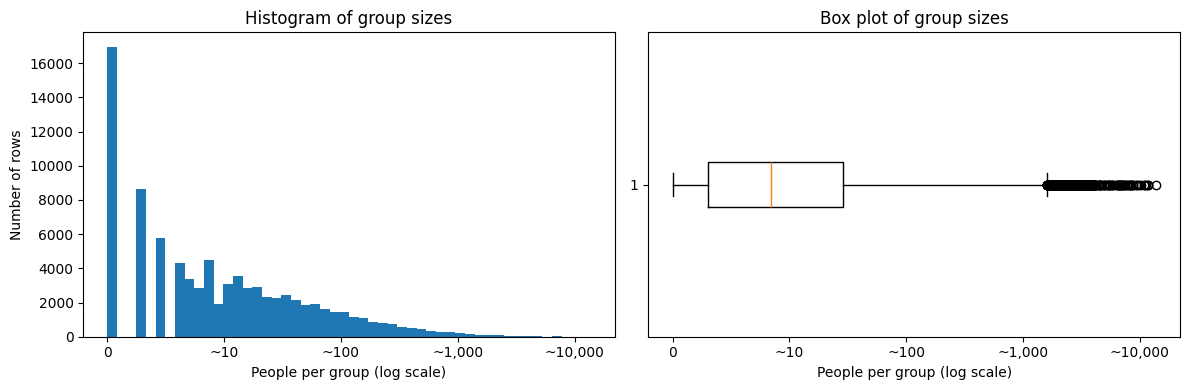

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(log_count, bins=50)
ax[0].set_title("Histogram of group sizes")
ax[0].set_ylabel("Number of rows")

ax[1].boxplot(log_count, vert=False)
ax[1].set_title("Box plot of group sizes")

# Show real people counts instead of log values
ticks = [0, 1, 2, 3, 4]
labels = ["0", "~10", "~100", "~1,000", "~10,000"]
for a in ax:
    a.set_xticks(ticks)
    a.set_xticklabels(labels)
    a.set_xlabel("People per group (log scale)")

plt.tight_layout()
plt.show()

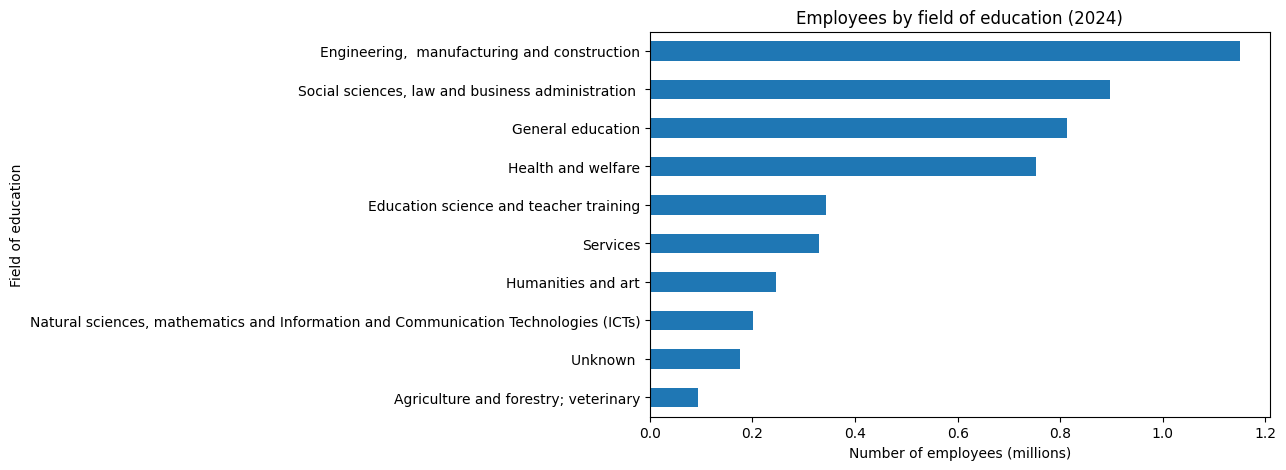

UtbinriktnSUN2020_name
Agriculture and forestry; veterinary                                                    1.9
Unknown                                                                                 3.5
Natural sciences, mathematics and Information and Communication Technologies (ICTs)     4.0
Humanities and art                                                                      4.9
Services                                                                                6.6
Education science and teacher training                                                  6.9
Health and welfare                                                                     15.0
General education                                                                      16.3
Social sciences, law and business administration                                       17.9
Engineering,  manufacturing and construction                                           23.0
Name: count, dtype: float64


In [14]:
by_edu = df.groupby("UtbinriktnSUN2020_name")["count"].sum().sort_values()

(by_edu / 1e6).plot.barh(figsize=(8, 5))
plt.title("Employees by field of education (2024)")
plt.xlabel("Number of employees (millions)")
plt.ylabel("Field of education")
plt.show()

print((by_edu / by_edu.sum() * 100).round(1))   # share in %

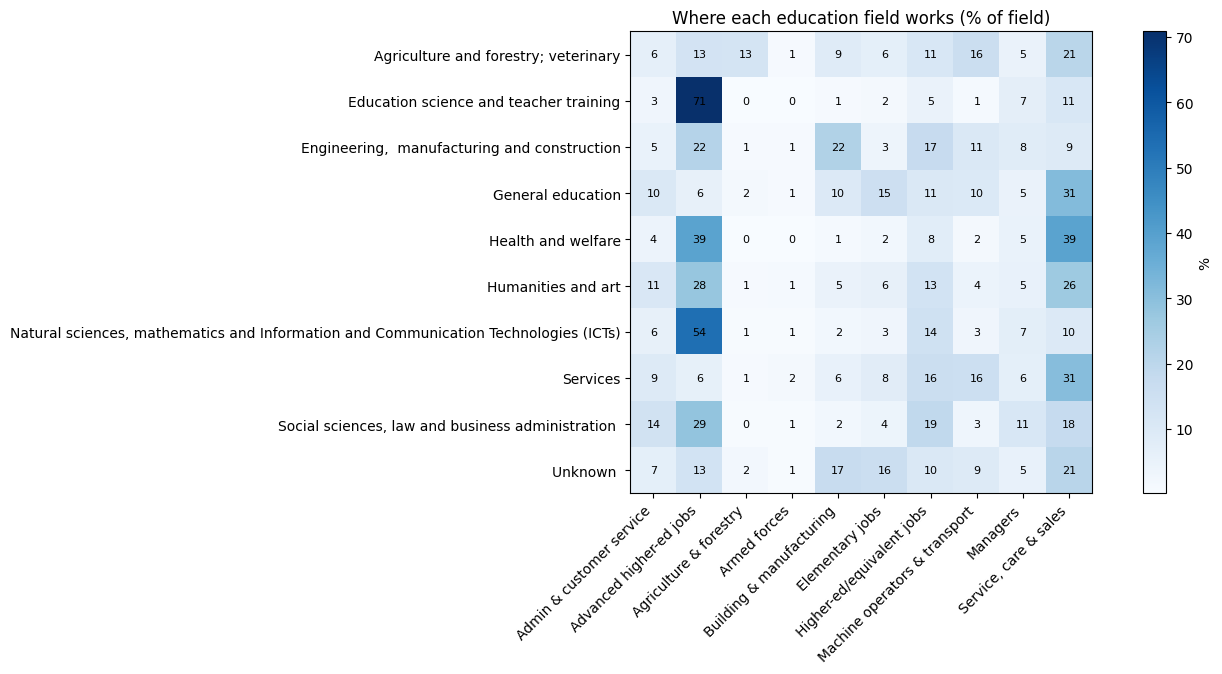

In [15]:
major_names = {
    "0": "Armed forces", "1": "Managers",
    "2": "Advanced higher-ed jobs", "3": "Higher-ed/equivalent jobs",
    "4": "Admin & customer service", "5": "Service, care & sales",
    "6": "Agriculture & forestry", "7": "Building & manufacturing",
    "8": "Machine operators & transport", "9": "Elementary jobs"
}
df["major_group"] = df["Yrke2012"].str[0].map(major_names)

# Table: rows = education field, columns = occupation group, values = employees
tab = df.pivot_table(index="UtbinriktnSUN2020_name", columns="major_group",
                     values="count", aggfunc="sum")

# Turn into % of each education field (each row adds up to 100%)
share = tab.div(tab.sum(axis=1), axis=0) * 100

plt.figure(figsize=(13, 6))
plt.imshow(share, cmap="Blues")
plt.xticks(range(len(share.columns)), share.columns, rotation=45, ha="right")
plt.yticks(range(len(share.index)), share.index)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        plt.text(j, i, f"{share.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8)
plt.title("Where each education field works (% of field)")
plt.colorbar(label="%")
plt.show()

In [16]:
# 1. Drop education codes 0 (General) and 9 (Unknown)
clean = df[~df["UtbinriktnSUN2020"].astype(str).isin(["0", "9"])]

# 2. Find and drop unknown occupations
unknown_occ = clean["Yrke2012_name"].str.contains("unknown", case=False)
print("Unknown occupations removed:", clean.loc[unknown_occ, "Yrke2012_name"].unique())
clean = clean[~unknown_occ]

# 3. Drop empty groups
clean = clean[clean["count"] > 0]

# Summary: how much did we keep?
print("Rows:", len(df), "->", len(clean))
print("Employees kept:", int(clean["count"].sum()),
      f"({clean['count'].sum() / df['count'].sum():.0%} of all)")

Unknown occupations removed: []
Rows: 86000 -> 54992
Employees kept: 4016061 (80% of all)


In [17]:
total = clean["count"].sum()
edu_col, occ_col = "UtbinriktnSUN2020_name", "Yrke2012_name"

# People per (education, occupation) pair, per education, per occupation
rules = clean.groupby([edu_col, occ_col])["count"].sum().reset_index(name="both")
edu_total = clean.groupby(edu_col)["count"].sum()
occ_total = clean.groupby(occ_col)["count"].sum()

# The three measures
rules["support"] = rules["both"] / total
rules["confidence"] = rules["both"] / rules[edu_col].map(edu_total)
rules["lift"] = rules["confidence"] / (rules[occ_col].map(occ_total) / total)

# Keep only well-supported rules (at least 0.1% of people, about 4,000) = noise reduction
strong = rules[rules["support"] >= 0.001]

# Show the top 3 rules per education field, by lift
top = strong.sort_values("lift", ascending=False).groupby(edu_col).head(3)
top.sort_values([edu_col, "lift"], ascending=[True, False])

,UtbinriktnSUN2020_name,Yrke2012_name,both,support,confidence,lift
787,Education science and teacher training,Special teachers and special needs teachers,14256,0.003550,0.041459,10.915906
721,Education science and teacher training,Preschool teachers,58757,0.014631,0.170874,10.838872
584,Education science and teacher training,"Headmasters, level 2",10484,0.002611,0.030489,10.104468
957,"Engineering, manufacturing and construction","Electricians, installation and service",33227,0.008274,0.028865,3.126951
962,"Engineering, manufacturing and construction",Engineering professionals in building construc...,13264,0.003303,0.011523,3.088406
956,"Engineering, manufacturing and construction",Electrical mechanics and fitters,6718,0.001673,0.005836,3.019243
1366,Health and welfare,Dentists,7655,0.001906,0.010169,5.313434
1610,Health and welfare,Resident physicians,11257,0.002803,0.014954,5.312300
1586,Health and welfare,Professional midwifes,6677,0.001663,0.008870,5.304761
2022,Humanities and art,Public relations professionals,4389,0.001093,0.017786,3.322547


                                                    lift >= 1.5  lift >= 2  \
UtbinriktnSUN2020_name                                                       
Humanities and art                                         44.2       28.3   
Social sciences, law and business administration           61.0       35.0   
Agriculture and forestry; veterinary                       39.9       37.1   
Services                                                   47.3       39.8   
Natural sciences, mathematics and Information a...         54.4       44.7   
Engineering,  manufacturing and construction               61.2       48.6   
Education science and teacher training                     71.8       68.9   
Health and welfare                                         75.3       71.1   

                                                    lift >= 3  
UtbinriktnSUN2020_name                                         
Humanities and art                                       15.3  
Social sciences, law and bu

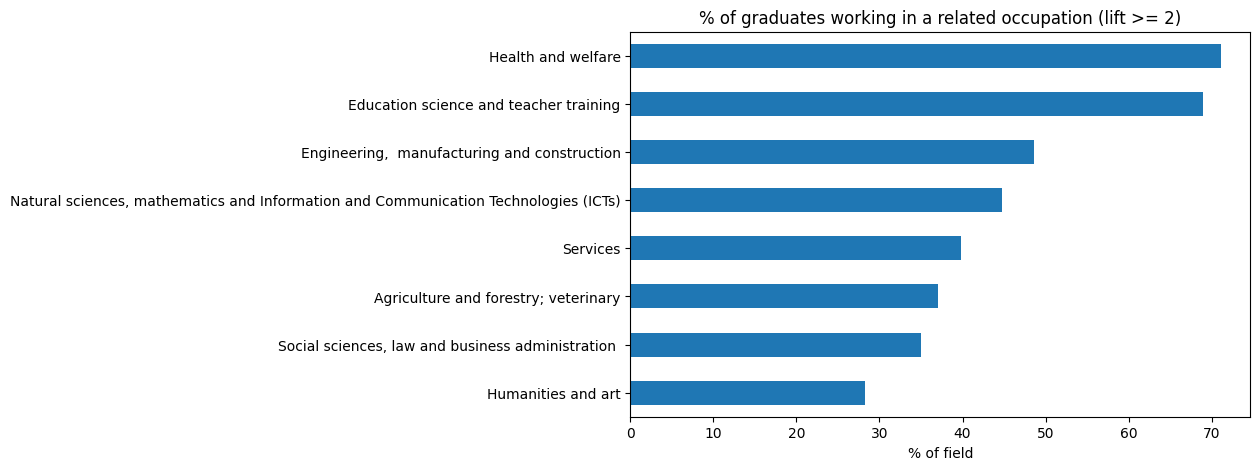

In [18]:
def related_share(min_lift, min_people=500):
    # Related = overrepresented (lift) AND backed by enough people (noise reduction)
    r = rules[(rules["lift"] >= min_lift) & (rules["both"] >= min_people)]
    return r.groupby(edu_col)["confidence"].sum() * 100

result = pd.DataFrame({f"lift >= {t}": related_share(t) for t in [1.5, 2, 3]})
result = result.round(1).sort_values("lift >= 2")
print(result)

result["lift >= 2"].plot.barh(figsize=(8, 5))
plt.title("% of graduates working in a related occupation (lift >= 2)")
plt.xlabel("% of field")
plt.ylabel("")
plt.show()